# 🏆 FIFA World Cup 2026 — Top Goal Scorer Predictor
This notebook predicts which player will score the most goals in FIFA World Cup 2026.

**Pipeline:**
1. Load & explore historical WC player data (2014, 2018, 2022)
2. Feature engineering
3. Train XGBoost regression model
4. Predict on 2026 squads

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [24]:
df=pd.read_csv("Cleaned_ML_Dataset.csv")

In [25]:
df.head()

,Player,Rk,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Goals,Shots,SoT,SoT%,G/Sh,G/SoT,ShoDist,ShoFK,ShoPK,PKatt,PasTotCmp,PasTotAtt,PasTotCmp%,PasTotDist,PasTotPrgDist,PasShoCmp,PasShoAtt,PasShoCmp%,PasMedCmp,PasMedAtt,PasMedCmp%,PasLonCmp,PasLonAtt,PasLonCmp%,Assists,PasAss,Pas3rd,PPA,CrsPA,PasProg,PasAtt,PasLive,PasDead,PasFK,TB,PasPress,Sw,PasCrs,CK,CkIn,CkOut,CkStr,PasGround,PasLow,PasHigh,PaswLeft,PaswRight,PaswHead,TI,PaswOther,PasCmp,PasOff,PasOut,PasInt,PasBlocks,SCA,ScaPassLive,ScaPassDead,ScaDrib,ScaSh,ScaFld,ScaDef,GCA,GcaPassLive,GcaPassDead,GcaDrib,GcaSh,GcaFld,GcaDef,Tkl,TklWon,TklDef3rd,TklMid3rd,TklAtt3rd,TklDri,TklDriAtt,TklDri%,TklDriPast,Press,PresSucc,Press%,PresDef3rd,PresMid3rd,PresAtt3rd,Blocks,BlkSh,BlkShSv,BlkPass,Int,Tkl+Int,Clr,Err,Touches,TouDefPen,TouDef3rd,TouMid3rd,TouAtt3rd,TouAttPen,TouLive,DriSucc,DriAtt,DriSucc%,DriPast,DriMegs,Carries,CarTotDist,CarPrgDist,CarProg,Car3rd,CPA,CarMis,CarDis,RecTarg,Rec,Rec%,RecProg,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,?tefan Radu,2200,ROU,DF,Lazio,Serie A,35.0,1986,10,6,556,6.2,0.00,0.32,0.16,50.0,0.00,0.00,23.9,0.00,0.0,0.0,43.10,52.6,81.9,748.4,301.90,19.20,21.00,91.5,20.50,24.50,83.6,2.74,5.48,50.0,0.0,0.16,3.39,0.00,0.00,2.58,52.6,46.3,6.29,0.48,0.0,4.68,0.32,1.13,0.00,0.00,0.00,0.0,36.30,6.94,9.35,36.80,6.61,2.26,5.81,0.00,43.10,0.00,1.29,1.94,1.29,0.32,0.32,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,1.29,0.81,0.65,0.65,0.00,0.48,1.45,33.3,0.97,8.87,2.90,32.7,3.87,4.68,0.32,1.45,0.32,0.0,1.13,1.61,2.90,3.06,0.00,61.1,5.97,27.1,29.00,7.74,0.65,55.0,0.32,0.48,66.7,0.48,0.0,35.8,173.5,75.5,2.58,0.48,0.00,0.32,0.48,39.7,38.1,95.9,0.16,0.32,0.0,0.0,0.81,0.97,0.00,1.13,0.81,0.0,0.00,0.0,7.74,2.10,1.77,54.2
1,?ukasz Fabia?ski,843,POL,GK,West Ham,Premier League,37.0,1985,37,37,3330,37.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.0,17.20,27.2,63.2,628.3,407.60,1.81,1.81,100.0,6.05,6.11,99.1,9.08,19.00,47.9,0.0,0.03,0.30,0.00,0.00,0.00,27.2,17.8,9.43,1.86,0.0,2.05,0.70,0.00,0.00,0.00,0.00,0.0,10.40,1.14,15.60,1.57,19.90,0.11,0.00,3.92,17.20,0.00,0.84,0.14,0.08,0.08,0.05,0.03,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.03,0.03,100.0,0.03,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,29.1,26.90,29.1,0.05,0.00,0.00,19.8,0.00,0.00,0.0,0.00,0.0,11.9,63.3,32.8,0.00,0.00,0.00,0.00,0.00,11.2,11.1,99.0,0.00,0.05,0.0,0.0,0.03,0.19,0.00,0.00,0.00,0.0,0.03,0.0,3.84,0.00,0.00,0.0
2,?ukasz Skorupski,2514,POL,GK,Bologna,Serie A,31.0,1991,36,36,3240,36.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.0,26.20,35.0,75.0,748.9,445.60,5.28,5.36,98.4,8.56,8.72,98.1,10.50,18.90,55.3,0.0,0.00,0.11,0.00,0.00,0.00,35.0,23.5,11.50,3.50,0.0,1.83,1.39,0.00,0.00,0.00,0.00,0.0,18.00,1.39,15.60,2.97,26.20,0.06,0.00,4.56,26.20,0.11,1.06,0.19,0.08,0.03,0.00,0.03,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.0,0.03,0.14,0.03,20.0,0.14,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.03,37.9,33.90,37.8,0.11,0.00,0.00,26.5,0.00,0.00,0.0,0.00,0.0,17.3,76.9,38.5,0.00,0.00,0.00,0.03,0.00,16.5,16.4,99.5,0.00,0.11,0.0,0.0,0.06,0.17,0.00,0.00,0.00,0.0,0.06,0.0,4.50,0.00,0.03,0.0
3,Aaron Connolly,560,IRL,FW,Brighton,Premier League,22.0,2000,4,1,156,1.7,0.00,1.18,0.00,0.0,0.00,0.00,14.9,0.00,0.0,0.0,8.82,10.6,83.3,124.7,5.88,5.29,6.47,81.8,3.53,4.12,85.7,0.00,0.00,0.0,0.0,0.59,0.00,0.00,0.00,0.00,10.6,10.0,0.59,0.00,0.0,3.53,0.00,0.59,0.00,0.00,0.00,0.0,8.82,1.76,0.00,0.59,8.82,0.00,0.00,1.18,8.82,0.00,0.00,0.59,0.59,1.18,1.18,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.59,0.0,0.59,15.90,2.94,18.5,2.35,6.47,7.06,1.18,0.00,0.0,1.18,0.00,0.00,0.00,0.00,20.0,0.00,0.0,8.24,12.40,2.35,19.4,0.00,0.59,0.0,0.00,0.0,12.9,77.6,24.7,1.76,0.00,0.00,1.76,0.59,38.2,12.9,33.8,4.12,0.00,0.0,0.0,0.59,4.12,0.00,0.59,0.00,0.0,0.00,0.0,4.12,0.00,4.12,0.0
4,Aaron Cresswell,594,ENG,DF,West Ham,Premier League,32.0,1989,31,31,2726,30.3,0.07,0.59,0.1

In [26]:
df.columns


Index(['Player', 'Rk', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'Off', 'Crs', 'TklW', 'PKwon', 'PKcon', 'OG', 'Recov', 'AerWon',
       'AerLost', 'AerWon%'],
      dtype='str', length=143)

In [27]:
print(df.isnull().sum().to_string())
print(df.shape)

Player           0
Rk               0
Nation           1
Pos              0
Squad            0
Comp             0
Age              0
Born             0
MP               0
Starts           0
Min              0
90s              0
Goals            0
Shots            0
SoT              0
SoT%             0
G/Sh             0
G/SoT            0
ShoDist          0
ShoFK            0
ShoPK            0
PKatt            0
PasTotCmp        0
PasTotAtt        0
PasTotCmp%       0
PasTotDist       0
PasTotPrgDist    0
PasShoCmp        0
PasShoAtt        0
PasShoCmp%       0
PasMedCmp        0
PasMedAtt        0
PasMedCmp%       0
PasLonCmp        0
PasLonAtt        0
PasLonCmp%       0
Assists          0
PasAss           0
Pas3rd           0
PPA              0
CrsPA            0
PasProg          0
PasAtt           0
PasLive          0
PasDead          0
PasFK            0
TB               0
PasPress         0
Sw               0
PasCrs           0
CK               0
CkIn             0
CkOut       

In [28]:
df["Pos"].value_counts()

Pos
DF      909
MF      576
FW      386
FWMF    285
MFFW    229
GK      214
MFDF     63
DFMF     59
DFFW     35
FWDF     29
GKMF      1
Name: count, dtype: int64

In [29]:
df["Goals"].describe()

count    2786.000000
mean        0.116665
std         0.243988
min         0.000000
25%         0.000000
50%         0.000000
75%         0.160000
max         5.000000
Name: Goals, dtype: float64

In [30]:
df_goals = df[-df['Pos'].str.contains('GK')].reset_index(drop=True)
print(f"Players after removing GK: {len(df_goals)}")

Players after removing GK: 2571


In [31]:
print(f"Original: {len(df)}")
print(f"After removing GK: {len(df_goals)}")
print(f"Removed: {len(df) - len(df_goals)}")

Original: 2786
After removing GK: 2571
Removed: 215


In [32]:
cols = ["Player", "Nation", "Pos", "Squad", "Age",
        "MP", "Starts", "Min", "Goals", "Shots", 
        "SoT", "SoT%", "G/Sh", "G/SoT", "ShoDist",
        "ShoPK", "PKatt", "Assists", "SCA", "GCA",
        "PPA", "CarProg", "Car3rd", "CPA","Comp"]

df_goals = df_goals[cols].copy()
print(df_goals.shape)
df_goals.head()

(2571, 25)


,Player,Nation,Pos,Squad,Age,MP,Starts,Min,Goals,Shots,SoT,SoT%,G/Sh,G/SoT,ShoDist,ShoPK,PKatt,Assists,SCA,GCA,PPA,CarProg,Car3rd,CPA,Comp
0,?tefan Radu,ROU,DF,Lazio,35.0,10,6,556,0.00,0.32,0.16,50.0,0.00,0.00,23.9,0.0,0.0,0.00,0.32,0.00,0.00,2.58,0.48,0.00,Serie A
1,Aaron Connolly,IRL,FW,Brighton,22.0,4,1,156,0.00,1.18,0.00,0.0,0.00,0.00,14.9,0.0,0.0,0.00,1.18,0.00,0.00,1.76,0.00,0.00,Premier League
2,Aaron Cresswell,ENG,DF,West Ham,32.0,31,31,2726,0.07,0.59,0.10,16.7,0.11,0.67,19.9,0.0,0.0,0.10,1.62,0.17,0.79,3.63,1.55,0.07,Premier League
3,Aaron Hickey,SCO,DF,Bologna,19.0,36,34,2820,0.16,0.67,0.42,61.9,0.24,0.38,21.0,0.0,0.0,0.03,1.25,0.13,0.70,4.22,1.44,0.32,Serie A
4,Aaron Lennon,ENG,MF,Burnley,35.0,28,17,1551,0.12,0.70,0.23,33.3,0.17,0.50,19.3,0.0,0.0,0.00,1.86,0.29,0.29,3.26,0.76,1.05,Premier League


In [33]:
# Avoid division by zero
df_goals["Min"] = df_goals["Min"].replace(0, np.nan)
df_goals = df_goals.dropna(subset=["Min"]).reset_index(drop=True)

# Per 90 features
df_goals["Goals_per90"]  = (df_goals["Goals"] / df_goals["Min"]) * 90
df_goals["Shots_per90"]  = (df_goals["Shots"] / df_goals["Min"]) * 90
df_goals["SoT_per90"]    = (df_goals["SoT"]   / df_goals["Min"]) * 90
df_goals["SCA_per90"]    = (df_goals["SCA"]   / df_goals["Min"]) * 90
df_goals["GCA_per90"]    = (df_goals["GCA"]   / df_goals["Min"]) * 90
df_goals["CPA_per90"]    = (df_goals["CPA"]   / df_goals["Min"]) * 90

# Is forward?
df_goals["Is_Forward"] = df_goals["Pos"].str.contains("FW").astype(int)

print(f"Shape after feature engineering: {df_goals.shape}")
df_goals[["Player", "Goals_per90", "Shots_per90", "Is_Forward"]].head(10)

Shape after feature engineering: (2571, 32)


,Player,Goals_per90,Shots_per90,Is_Forward
0,?tefan Radu,0.000000,0.051799,0
1,Aaron Connolly,0.000000,0.680769,1
2,Aaron Cresswell,0.002311,0.019479,0
3,Aaron Hickey,0.005106,0.021383,0
4,Aaron Lennon,0.006963,0.040619,0
5,Aaron Ramsey,0.000000,0.000000,0
6,Aaron Wan-Bissaka,0.000000,0.012549,0
7,Aarón Martín,0.001571,0.027880,0
8,Abdel Jalil Medioub,0.000000,0.062219,0
9,Abdelhamid Sabiri,0.030235,0.163270,1


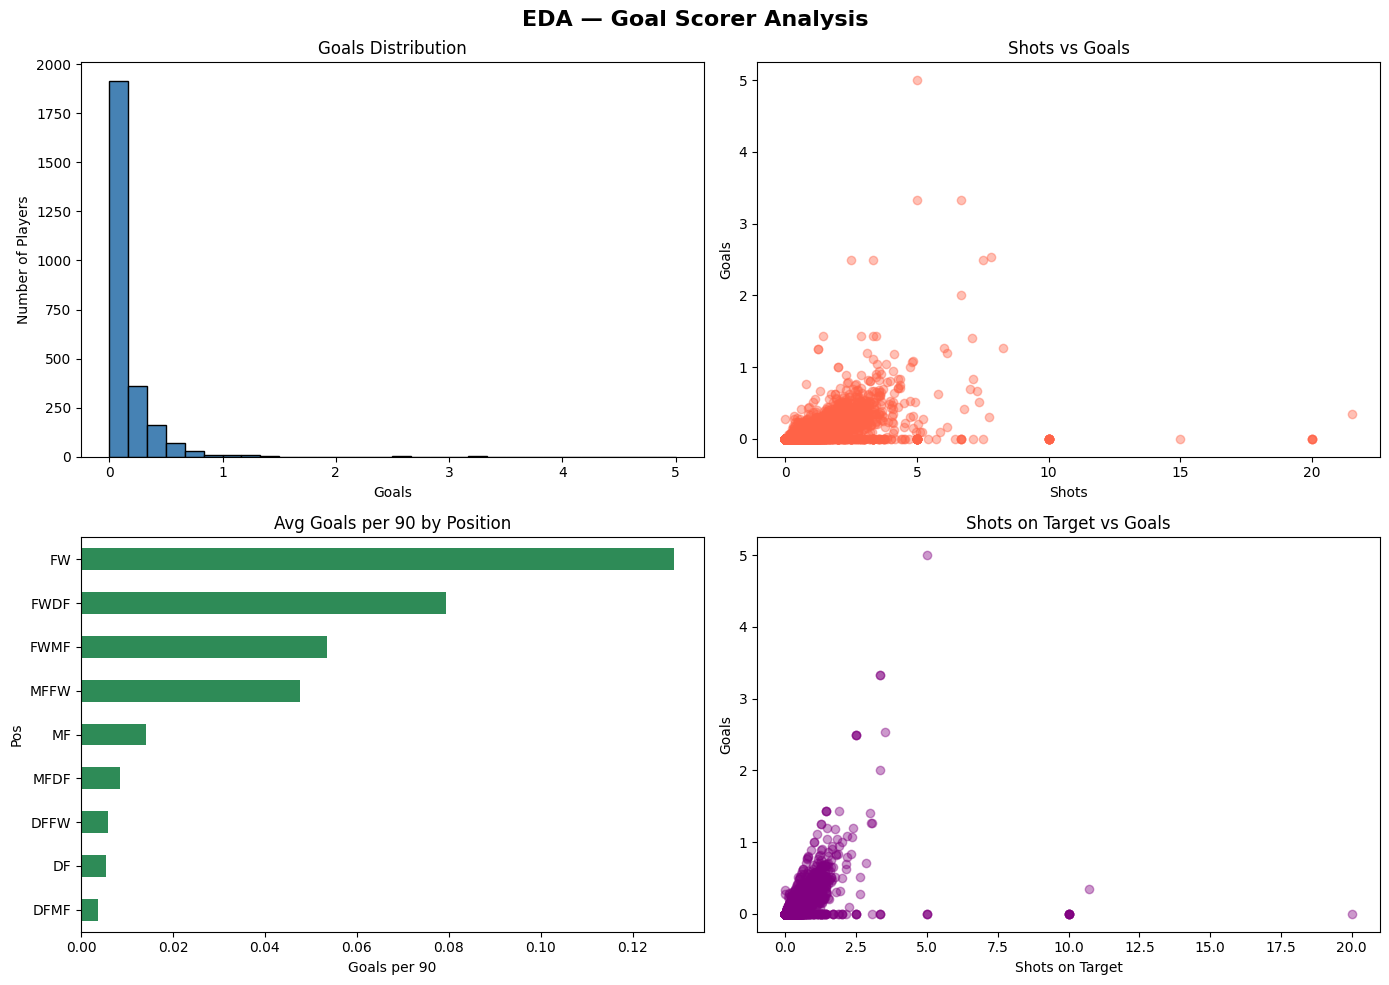

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Goals distribution
axes[0,0].hist(df_goals["Goals"], bins=30, color="steelblue", edgecolor="black")
axes[0,0].set_title("Goals Distribution")
axes[0,0].set_xlabel("Goals")
axes[0,0].set_ylabel("Number of Players")

# 2. Shots vs Goals
axes[0,1].scatter(df_goals["Shots"], df_goals["Goals"], alpha=0.4, color="tomato")
axes[0,1].set_title("Shots vs Goals")
axes[0,1].set_xlabel("Shots")
axes[0,1].set_ylabel("Goals")

# 3. Goals per 90 by Position
df_goals.groupby("Pos")["Goals_per90"].mean().sort_values().plot(
    kind="barh", ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Avg Goals per 90 by Position")
axes[1,0].set_xlabel("Goals per 90")

# 4. SoT vs Goals
axes[1,1].scatter(df_goals["SoT"], df_goals["Goals"], alpha=0.4, color="purple")
axes[1,1].set_title("Shots on Target vs Goals")
axes[1,1].set_xlabel("Shots on Target")
axes[1,1].set_ylabel("Goals")

plt.suptitle("EDA — Goal Scorer Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [35]:
features = ["MP", "Starts", "Shots", "SoT", "SoT%",
            "G/Sh", "G/SoT", "ShoDist", "ShoPK", "PKatt",
            "SCA", "GCA", "PPA", "CarProg", "Car3rd", "CPA",
            "Goals_per90", "Shots_per90", "SoT_per90",
            "SCA_per90", "GCA_per90", "CPA_per90",
            "Is_Forward", "Age"]

target = "Goals"

X = df_goals[features]
y = df_goals[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 2056
Test size:  515


In [36]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)
print("✅ Model trained successfully!")

✅ Model trained successfully!


In [37]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 0.012
R²  : 0.954


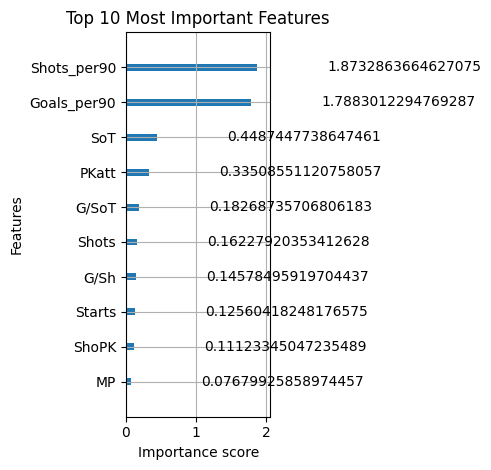

In [38]:
xgb.plot_importance(model, max_num_features=10, 
                    importance_type="gain",
                    title="Top 10 Most Important Features")
plt.tight_layout()
plt.show()

In [39]:
df_goals["Predicted_Goals"] = model.predict(X)

top15 = df_goals.sort_values("Predicted_Goals", ascending=False)[
    ["Player", "Nation", "Pos", "Squad", "Goals", "Predicted_Goals"]
].head(15).reset_index(drop=True)

top15.index += 1
print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15.to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                       Player Nation   Pos                  Squad  Goals  Predicted_Goals
1               Pablo Sarabia    ESP    FW              Paris S-G   5.00         4.908413
2         Fernando Forestieri    ITA  FWMF                Udinese   3.33         3.337370
3             Delano Burgzorg    NED    FW               Mainz 05   3.33         3.314673
4             Moustapha Cissé    GUI    FW               Atalanta   2.50         2.521786
5                Simone Verdi    ITA  FWMF      SalernitanaTorino   2.54         2.518377
6            Cristian Volpato    AUS  MFFW                   Roma   2.50         2.500636
7                Divock Origi    BEL    FW              Liverpool   2.00         1.976237
8              Steffen Tigges    GER  FWMF               Dortmund   2.50         1.660046
9             Clément Grenier    FRA    MF               Mallorca   1.43         1.434005
10          Donny van de Beek    NED    MF  Ma

In [40]:
print(df["Comp"].value_counts())

Comp
La Liga                         562
Serie A                         558
Ligue 1                         556
Premier League                  495
Bundesliga                      481
Serie ASerie A                   24
La LigaLa Liga                   14
Ligue 1Ligue 1                   13
BundesligaBundesliga             12
Premier LeaguePremier League      9
Premier LeagueLa Liga             8
La LigaPremier League             5
Serie APremier League             5
Premier LeagueSerie A             5
Serie ABundesliga                 5
Serie ALa Liga                    4
Ligue 1Premier League             4
Ligue 1La Liga                    4
BundesligaLa Liga                 3
BundesligaSerie A                 3
Premier LeagueLigue 1             3
BundesligaLigue 1                 2
BundesligaPremier League          2
Ligue 1Bundesliga                 2
Serie ALigue 1                    2
Ligue 1Serie A                    1
La LigaLigue 1Ligue 1             1
La LigaSerie A         

In [41]:
# Keep only clean single-league entries
clean_comps = ["La Liga", "Serie A", "Ligue 1", 
               "Premier League", "Bundesliga"]
df_goals = df_goals[df_goals["Comp"].isin(clean_comps)].reset_index(drop=True)
print(f"Players after cleaning: {len(df_goals)}")

Players after cleaning: 2439


In [42]:
print(df.columns[df.columns.str.contains("season|year|Season|Year")].tolist())

[]


In [43]:
print(df["Squad"].value_counts().head(20))

Squad
Salernitana      39
Saint-Étienne    37
Venezia          37
Genoa            36
Metz             36
Bologna          35
Bordeaux         34
Reims            34
Paris S-G        33
Troyes           33
Espanyol         33
Stuttgart        32
Barcelona        31
Mallorca         31
Real Sociedad    31
Hoffenheim       31
Dortmund         31
Granada          30
Spezia           30
Levante          30
Name: count, dtype: int64


In [44]:
df_goals["Predicted_Goals"] = model.predict(df_goals[features])

top15 = df_goals.sort_values("Predicted_Goals", ascending=False)[
    ["Player", "Nation", "Pos", "Squad", "Goals", "Predicted_Goals"]
].head(15).reset_index(drop=True)

top15.index += 1
print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15.to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                 Player Nation   Pos          Squad  Goals  Predicted_Goals
1         Pablo Sarabia    ESP    FW      Paris S-G   5.00         4.908413
2   Fernando Forestieri    ITA  FWMF        Udinese   3.33         3.337370
3       Delano Burgzorg    NED    FW       Mainz 05   3.33         3.314673
4       Moustapha Cissé    GUI    FW       Atalanta   2.50         2.521786
5      Cristian Volpato    AUS  MFFW           Roma   2.50         2.500636
6          Divock Origi    BEL    FW      Liverpool   2.00         1.976237
7        Steffen Tigges    GER  FWMF       Dortmund   2.50         1.660046
8       Clément Grenier    FRA    MF       Mallorca   1.43         1.434005
9    Federico Santander    PAR  FWDF        Bologna   1.43         1.268941
10      Takumi Minamino    JPN  FWMF      Liverpool   1.43         1.267819
11         Edoardo Bove    ITA  MFFW           Roma   1.25         1.250656
12        Jeff Hendrick    IRL    

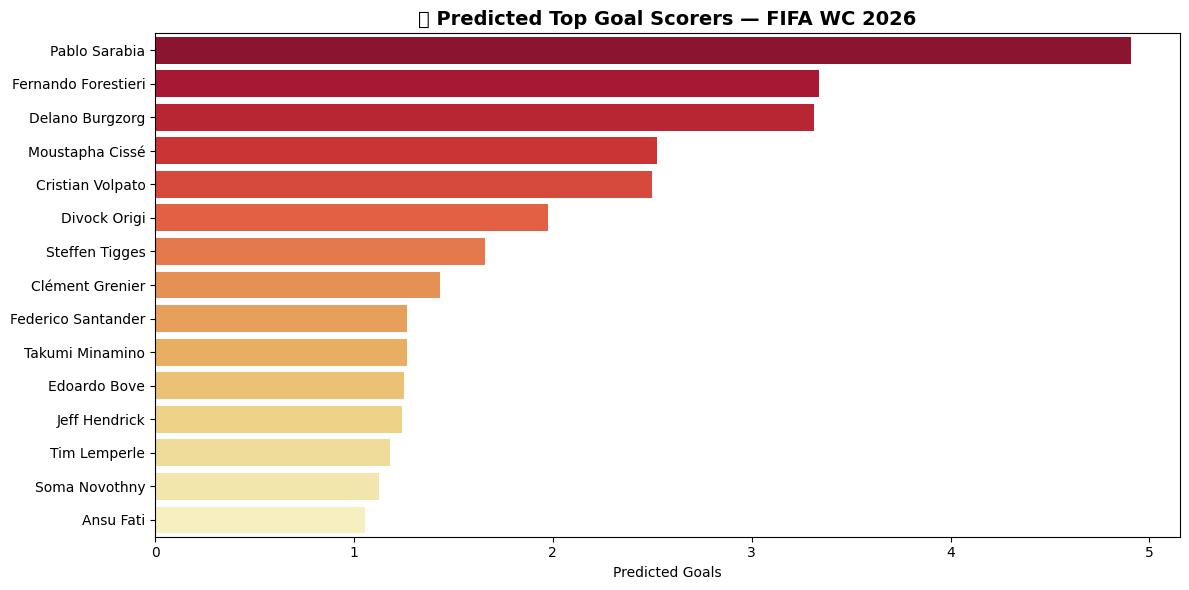

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top15, x="Predicted_Goals", y="Player",
            palette="YlOrRd_r")

plt.title("🏆 Predicted Top Goal Scorers — FIFA WC 2026", 
          fontsize=14, fontweight="bold")
plt.xlabel("Predicted Goals")
plt.ylabel("")
plt.tight_layout()
plt.show()